<!-- colab-badge -->
[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bmnogueira-ufms/IA-2026-02/blob/main/Aulas%20Pr%C3%A1ticas/aula04-redes-neurais/aula04-gabarito.ipynb)

# Aula 04 - Redes Neurais - Gabarito

**Inteligência Artificial - Graduação**
Prof. Bruno Nogueira - FACOM/UFMS - 2026/2

---

## Do que trata esta aula

A aula 03 terminou com uma dívida e uma pergunta.

A **dívida**: implementar a regressão logística do zero, com a função de custo de
entropia cruzada e o gradiente descendente. Pagamos ela na seção 1 - e não por
obrigação: a unidade básica de uma rede neural **é** um regressor logístico, então
escrever esse código é escrever o primeiro neurônio da aula.

A **pergunta**: no exercício do XOR, nenhuma reta separava os quatro pontos. Dissemos
que faltava "flexibilidade" e que termos polinomiais resolviam. Hoje vem a outra
saída, a que escala: em vez de uma hipótese mais complicada, **várias hipóteses
simples empilhadas**. Uma unidade logística separa por uma reta; três unidades
logísticas ligadas em duas camadas desenham o XOR sem nenhum termo quadrático.

É essa a ideia das **redes neurais**: neurônios simples, muitos, conectados em
camadas, em que cada camada enxerga não os atributos originais, mas **atributos
inventados pela camada anterior**.

### Roteiro

| # | Tema | Conceito da teoria |
|---|------|--------------------|
| 1 | A dívida da aula 03: logística do zero | entropia cruzada, gradiente |
| 2 | O neurônio artificial | soma ponderada + ativação |
| 3 | O perceptron | regra de atualização, o traço do AND |
| 4 | Onde o perceptron trava | não convergência no XOR |
| 5 | Regra delta e unidade sigmoide | por que a ativação precisa derivar |
| 6 | Duas saídas para o não linear | polinômio $O(n^3)$ × combinar unidades |
| 7 | A arquitetura da rede | camadas, matrizes $\Theta$, dimensões |
| 8 | Forward propagation | a rede XNOR dos slides |
| 9 | A rede inventa seus atributos | o espaço da camada escondida |
| 10 | Backpropagation | as duas fases, conferidas numericamente |
| 11 | Mais de duas classes | um neurônio por classe, dígitos |

> **Gabarito.** Este é o mesmo notebook da aula, com as lacunas preenchidas e todas as células executadas. As respostas das perguntas de interpretação estão em células de markdown marcadas com **🎯 Conclusão**.

---
## 0. Preparando o ambiente

As bibliotecas de sempre. A novidade é `sklearn.neural_network.MLPClassifier` - o
*Multi-Layer Perceptron*, que só aparece da seção 9 em diante. Até lá, tudo é NumPy.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore")

# Semente aleatória: garante que TODOS na sala obtenham os mesmos números.
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams.update({
    "figure.figsize": (7, 4.2),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Paleta segura para daltônicos, a mesma das aulas 01 a 03.
CORES = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
MAPA_REGIOES = ListedColormap(["#D6DEEC", "#F7DFCE"])

print(f"NumPy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print("\nAmbiente pronto.")

NumPy        2.4.4
pandas       3.0.2
scikit-learn 1.8.0

Ambiente pronto.


---
## 1. A dívida da aula 03: a regressão logística do zero

Na aula 03 o `LogisticRegression` encontrou o $\theta$ para nós. Hoje escrevemos esse
treinamento à mão - é o último algoritmo "de uma unidade só" antes de empilhar várias.

Voltamos aos **mesmos dados**: Adélie × Chinstrap pelo comprimento do bico. Assim
podemos comparar o nosso $\theta$ com o da biblioteca, número a número.

In [2]:
CAMINHO_LOCAL = Path("../../dados/penguins.csv")
URL_FALLBACK = ("https://raw.githubusercontent.com/bmnogueira-ufms/IA-2026-02/"
                "main/dados/penguins.csv")

if CAMINHO_LOCAL.exists():
    bruto = pd.read_csv(CAMINHO_LOCAL)
    print(f"Base carregada do arquivo local: {CAMINHO_LOCAL}")
else:
    bruto = pd.read_csv(URL_FALLBACK)
    print("Base baixada da internet.")

RENOMEAR = {
    "species": "especie", "island": "ilha", "bill_length_mm": "bico_comprimento",
    "bill_depth_mm": "bico_profundidade", "flipper_length_mm": "nadadeira",
    "body_mass_g": "massa_g", "sex": "sexo",
}
pinguins = bruto.rename(columns=RENOMEAR)

duas = pinguins[pinguins["especie"].isin(["Adelie", "Chinstrap"])].copy()
duas = duas.dropna(subset=["bico_comprimento", "bico_profundidade"])
y = (duas["especie"] == "Chinstrap").astype(int).to_numpy()
X = duas[["bico_comprimento"]].to_numpy(dtype=float)

print(f"\n{len(y)} pinguins - {int(y.sum())} Chinstrap (classe 1), "
      f"{int((1 - y).sum())} Adélie (classe 0)")

Base carregada do arquivo local: ../../dados/penguins.csv

219 pinguins - 68 Chinstrap (classe 1), 151 Adélie (classe 0)


### A hipótese e a função de custo

A hipótese é a da aula 03: a sigmoide aplicada a uma combinação linear.

$$h_\theta(x) = g(\theta^T x), \qquad g(z) = \frac{1}{1 + e^{-z}}$$

O que faltava era o **custo**. Por que não usar o erro quadrático da regressão linear?
Porque com $h$ passando pela sigmoide, aquele custo deixa de ser **convexo** - ganha
vales locais, e o gradiente descendente fica preso no primeiro em que cair. A escolha
certa é a **entropia cruzada**:

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}
  \left[ y^{(i)} \log h(x^{(i)}) + (1 - y^{(i)}) \log\left(1 - h(x^{(i)})\right) \right]$$

Leia a fórmula como duas punições que nunca agem juntas: se $y = 1$, sobra
$-\log h(x)$, que vale 0 quando o modelo cravou 1 e vai para o infinito quando ele
cravou 0. Se $y = 0$, sobra o espelho. **Errar com confiança custa caro** - e é essa
a diferença em relação ao erro quadrático, que pune no máximo 1 por exemplo.

In [3]:
def sigmoide(z):
    """A mesma da aula 03."""
    z = np.asarray(z, dtype=float)
    return 1.0 / (1.0 + np.exp(-z))


def com_bias(X):
    """Acrescenta a coluna x0 = 1 à esquerda (o termo do bias)."""
    X = np.asarray(X, dtype=float)
    return np.c_[np.ones(len(X)), X]


def padroniza(X):
    """Escore z, como na aula 02. Devolve X padronizado, médias e desvios."""
    X = np.asarray(X, dtype=float)
    mu, sigma = X.mean(axis=0), X.std(axis=0)
    return (X - mu) / sigma, mu, sigma


Xz, MU, SIGMA = padroniza(X)
Xb = com_bias(Xz)
print(f"X com bias: {Xb.shape}  (m = {Xb.shape[0]} exemplos, n + 1 = {Xb.shape[1]} colunas)")
print(f"Médias usadas na padronização: {MU.round(3)}   desvios: {SIGMA.round(3)}")

X com bias: (219, 2)  (m = 219 exemplos, n + 1 = 2 colunas)
Médias usadas na padronização: [41.91]   desvios: [5.465]


### 🔨 IMPLEMENTE 1 - a entropia cruzada

In [4]:
def custo_logistico(theta, Xb, y):
    """Entropia cruzada média.

    Parâmetros
    ----------
    theta : np.ndarray (n+1,)
    Xb    : np.ndarray (m, n+1), já com a coluna de bias
    y     : np.ndarray (m,) com 0 ou 1

    Devolve
    -------
    float
    """
    EPS = 1e-12
    h = sigmoide(Xb @ theta)
    return float(-np.mean(y * np.log(h + EPS) + (1 - y) * np.log(1 - h + EPS)))

In [5]:
# Conferência da IMPLEMENTE 1
theta_zero = np.zeros(Xb.shape[1])
# Com theta = 0, h(x) = g(0) = 0,5 para TODO exemplo. O custo vira -log(0,5) = ln 2.
assert np.isclose(custo_logistico(theta_zero, Xb, y), np.log(2), atol=1e-6), \
    "com theta = 0 o custo tem que ser ln 2 = 0,693..."
# Um modelo que acerta com confiança quase total paga quase nada.
h_certo = np.where(y == 1, 0.999, 0.001)
z_certo = np.log(h_certo / (1 - h_certo))
assert custo_logistico(np.array([1.0]), z_certo.reshape(-1, 1), y) < 0.002, \
    "acertar com confiança tem que custar quase zero"
# E errar com confiança paga MUITO.
assert custo_logistico(np.array([1.0]), (-z_certo).reshape(-1, 1), y) > 6, \
    "errar com confiança tem que custar caro"
print("OK - entropia cruzada correta.")
print(f"J(theta = 0)           = {custo_logistico(theta_zero, Xb, y):.6f}  (= ln 2)")
print(f"J(modelo quase certo)  = {custo_logistico(np.array([1.0]), z_certo.reshape(-1, 1), y):.6f}")
print(f"J(modelo quase errado) = {custo_logistico(np.array([1.0]), (-z_certo).reshape(-1, 1), y):.6f}")

OK - entropia cruzada correta.
J(theta = 0)           = 0.693147  (= ln 2)
J(modelo quase certo)  = 0.001001
J(modelo quase errado) = 6.907755


### Por que não o erro quadrático (o slide 14 da aula 03)

Vamos ver o estrago com os próprios olhos. Fixamos $\theta_0$ no valor ótimo e
varremos $\theta_1$, desenhando os dois custos lado a lado.

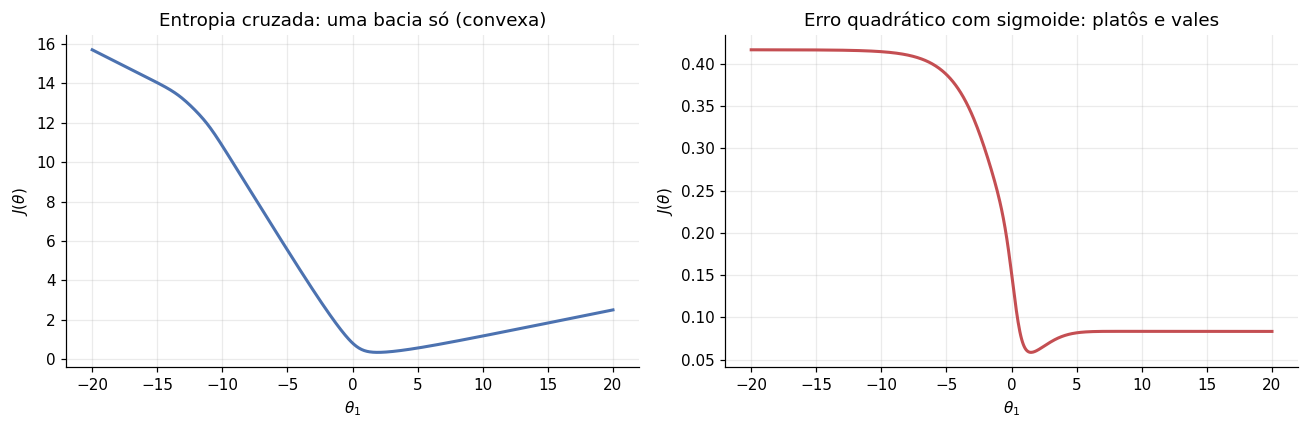

Inclinação do erro quadrático longe do ótimo (theta_1 = 20):
  dJ/dtheta_1 = -1.45e-08  -> o gradiente descendente praticamente PARA aqui.


In [6]:
def custo_quadratico(theta, Xb, y):
    """O custo da regressão linear, mas com h passando pela sigmoide."""
    h = sigmoide(Xb @ theta)
    return float(np.mean((h - y) ** 2) / 2)


# Um problema pequeno e propositalmente "torto", para o estrago ficar visível.
x_toy = np.array([-1.0, -0.6, 0.4, 0.8, 2.0, 2.4])
y_toy = np.array([0, 0, 1, 0, 1, 1])
Xb_toy = com_bias(x_toy.reshape(-1, 1))

grade = np.linspace(-20, 20, 600)
J_ent = [custo_logistico(np.array([-1.0, t]), Xb_toy, y_toy) for t in grade]
J_qua = [custo_quadratico(np.array([-1.0, t]), Xb_toy, y_toy) for t in grade]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(grade, J_ent, color=CORES[0], lw=2)
axes[0].set_title("Entropia cruzada: uma bacia só (convexa)")
axes[1].plot(grade, J_qua, color=CORES[3], lw=2)
axes[1].set_title("Erro quadrático com sigmoide: platôs e vales")
for ax in axes:
    ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$J(\theta)$")
plt.tight_layout()
plt.show()

print("Inclinação do erro quadrático longe do ótimo (theta_1 = 20):")
d = (custo_quadratico(np.array([-1.0, 20.001]), Xb_toy, y_toy)
     - custo_quadratico(np.array([-1.0, 19.999]), Xb_toy, y_toy)) / 0.002
print(f"  dJ/dtheta_1 = {d:.2e}  -> o gradiente descendente praticamente PARA aqui.")

🔎 **PARE E PENSE**: à direita o custo tem regiões quase planas (derivada ~ $10^{-9}$)
e mais de um fundo de vale. O gradiente descendente obedece à inclinação local; num
platô ele dá passos minúsculos e parece ter convergido, e num vale lateral ele para
de verdade, longe do melhor $\theta$. À esquerda, qualquer ponto de partida escorrega
para o mesmo fundo. É por isso que trocamos de função de custo.

### 🔨 IMPLEMENTE 2 - o gradiente

Aqui vem a surpresa boa da aula 02: apesar de $h$ e $J$ terem mudado completamente, a
derivada tem **exatamente a mesma cara** da regressão linear.

$$\frac{\partial J}{\partial \theta_j} =
  \frac{1}{m}\sum_{i=1}^{m}\left(h(x^{(i)}) - y^{(i)}\right) x_j^{(i)}$$

In [7]:
def gradiente_logistico(theta, Xb, y):
    """Vetor de derivadas parciais de J em relação a cada theta_j.

    Devolve
    -------
    np.ndarray (n+1,)
    """
    h = sigmoide(Xb @ theta)
    return Xb.T @ (h - y) / len(y)

In [8]:
# Conferência da IMPLEMENTE 2: comparação com diferenças centrais, como na aula 02.
theta_teste = np.array([0.3, -0.7])
analitico = gradiente_logistico(theta_teste, Xb, y)
EPS = 1e-6
numerico = np.array([
    (custo_logistico(theta_teste + EPS * np.eye(2)[j], Xb, y)
     - custo_logistico(theta_teste - EPS * np.eye(2)[j], Xb, y)) / (2 * EPS)
    for j in range(2)
])
assert analitico.shape == (2,), "o gradiente tem uma componente por parâmetro"
assert np.allclose(analitico, numerico, atol=1e-7), \
    f"analítico {analitico} != numérico {numerico}"
print("OK - gradiente correto.")
print(f"analítico: {analitico.round(8)}")
print(f"numérico:  {numerico.round(8)}")

OK - gradiente correto.
analítico: [ 0.25995451 -0.55489008]
numérico:  [ 0.25995451 -0.55489008]


### Treinando

Com custo e gradiente na mão, o laço é o mesmo da aula 02 - só que agora os dois
vêm da entropia cruzada.

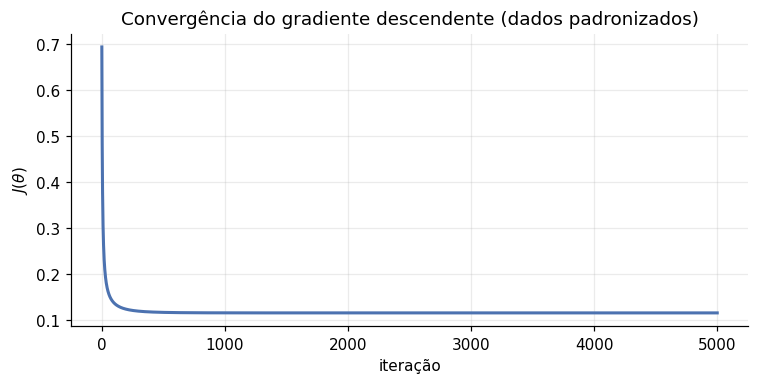

theta (padronizado): [-2.2891  5.733 ]
J final: 0.115321   J inicial: 0.693147


In [9]:
def gradiente_descendente(Xb, y, alpha=0.5, iteracoes=5000):
    """Gradiente descendente em lote. Devolve theta e o histórico do custo."""
    theta = np.zeros(Xb.shape[1])
    historico = []
    for _ in range(iteracoes):
        historico.append(custo_logistico(theta, Xb, y))
        theta = theta - alpha * gradiente_logistico(theta, Xb, y)
    return theta, np.array(historico)


theta_manual, historico = gradiente_descendente(Xb, y, alpha=0.5, iteracoes=5000)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(historico, color=CORES[0], lw=2)
ax.set_xlabel("iteração")
ax.set_ylabel(r"$J(\theta)$")
ax.set_title("Convergência do gradiente descendente (dados padronizados)")
plt.tight_layout()
plt.show()

print(f"theta (padronizado): {theta_manual.round(4)}")
print(f"J final: {historico[-1]:.6f}   J inicial: {historico[0]:.6f}")

In [10]:
# A prova dos nove: comparação com o scikit-learn.
from sklearn.linear_model import LogisticRegression

# C alto = quase sem regularização, que é o nosso caso (o "C" volta na aula 05).
sk = LogisticRegression(C=1e6, max_iter=10000).fit(Xz, y)
theta_sk = np.r_[sk.intercept_, sk.coef_.ravel()]

assert np.allclose(theta_manual, theta_sk, atol=0.01), \
    f"nosso {theta_manual} deveria bater com o da biblioteca {theta_sk}"
print("OK - o nosso theta bate com o do LogisticRegression.")
print(f"nosso:    {theta_manual.round(4)}")
print(f"sklearn:  {theta_sk.round(4)}")

# Desnormalizando (aula 02): voltamos aos milímetros do bico.
theta1_mm = theta_manual[1] / SIGMA[0]
theta0_mm = theta_manual[0] - theta_manual[1] * MU[0] / SIGMA[0]
limiar_mm = -theta0_mm / theta1_mm
acuracia = ((sigmoide(Xb @ theta_manual) >= 0.5).astype(int) == y).mean()
print(f"\nNa escala original: theta = [{theta0_mm:.3f}, {theta1_mm:.3f}]")
print(f"Fronteira de decisão: bico = {limiar_mm:.2f} mm   (a aula 03 achou 44,1 mm)")
print(f"Acurácia no treino: {acuracia:.1%}")

OK - o nosso theta bate com o do LogisticRegression.
nosso:    [-2.2891  5.733 ]
sklearn:  [-2.2863  5.7242]

Na escala original: theta = [-46.258, 1.049]
Fronteira de decisão: bico = 44.09 mm   (a aula 03 achou 44,1 mm)
Acurácia no treino: 95.0%


🎯 Dívida paga. E repare no que acabamos de construir: uma unidade que recebe
entradas, calcula $\theta^T x$, passa por uma função não linear e devolve um número
entre 0 e 1, com um algoritmo que ajusta os $\theta$ a partir do erro. **É um
neurônio.** O resto da aula é sobre o que acontece quando se coloca vários deles
juntos.

---
## 2. O neurônio artificial

O desenho dos slides tem quatro partes, e todas já apareceram na seção 1:

```
  x1 ──θ1──┐
  x2 ──θ2──┤
   ⋮       ├──►  Σ θi·xi  ──►  f( · )  ──►  y
  xn ──θn──┤        soma        função
  1  ──θ0──┘      ponderada    de ativação
```

1. **entradas** $x_1, \dots, x_n$ (os atributos), mais a entrada fixa $x_0 = 1$;
2. **pesos sinápticos** $\theta_0, \dots, \theta_n$ - os parâmetros que se aprende.
   O $\theta_0$ tem nome próprio, **bias**: é o quanto a unidade "puxa" para um lado
   mesmo sem entrada nenhuma;
3. a **soma ponderada** $z = \sum_i \theta_i x_i = \theta^T x$;
4. a **função de ativação** $f(z)$, que decide o que sai.

O que muda de um modelo de neurônio para outro é quase sempre o item 4.

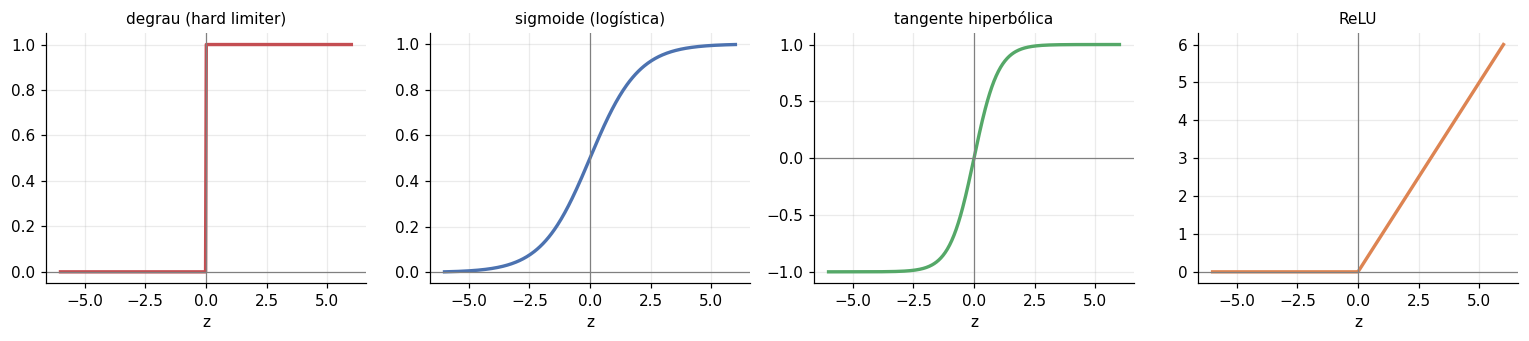

Derivável em z = 0?   degrau: NÃO    sigmoide: sim    tanh: sim    ReLU: quase


In [11]:
def degrau(z):
    """Hard limiter: 1 se z > 0, senão 0. O 'tudo ou nada' do perceptron."""
    return (np.asarray(z, dtype=float) > 0).astype(float)


def relu(z):
    """Retificadora: max(0, z). A ativação padrão das redes profundas de hoje."""
    return np.maximum(0.0, np.asarray(z, dtype=float))


zs = np.linspace(-6, 6, 400)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharex=True)
for ax, (nome, f, cor) in zip(axes, [
    ("degrau (hard limiter)", degrau, CORES[3]),
    ("sigmoide (logística)", sigmoide, CORES[0]),
    ("tangente hiperbólica", np.tanh, CORES[2]),
    ("ReLU", relu, CORES[1]),
]):
    ax.plot(zs, f(zs), color=cor, lw=2.2)
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(nome, fontsize=10)
    ax.set_xlabel("z")
plt.tight_layout()
plt.show()

print("Derivável em z = 0?   degrau: NÃO    sigmoide: sim    tanh: sim    ReLU: quase")

Guarde a última linha: o **degrau não tem derivada** no ponto que interessa. Isso vai
decidir, na seção 5, qual unidade pode ser treinada por gradiente descendente e qual
não pode.

---
## 3. O perceptron

O perceptron (Rosenblatt, 1958) é o neurônio com ativação em **degrau**:

$$h(x) = \begin{cases} 1, & \text{se } \theta_0 + \theta_1 x_1 + \cdots + \theta_n x_n > 0 \\
                       0, & \text{caso contrário} \end{cases}$$

A regra de aprendizado dos slides é de uma simplicidade desconcertante. Para cada
exemplo, um de cada vez:

1. calcule a saída $h(x^{(i)})$;
2. calcule o erro $E^{(i)} = y^{(i)} - h(x^{(i)})$;
3. se $E^{(i)} = 0$, não faça nada; senão, atualize **todos** os pesos:

$$\theta_j := \theta_j + \alpha \, E^{(i)} \, x_j^{(i)}$$

Repare no comportamento: $E$ só pode valer $0$, $+1$ ou $-1$. Quando a saída deveria
ser 1 e veio 0, todos os pesos ligados a entradas **ativas** sobem em $\alpha$ - a
unidade fica mais propensa a disparar naquele padrão. Quando é o contrário, descem.
Entradas que valem 0 não mudam nada, porque $x_j^{(i)} = 0$ zera a correção.

### 🔨 IMPLEMENTE 3 - o treinamento do perceptron

In [12]:
def treina_perceptron(X, y, alpha=0.5, epocas=10, verbose=False):
    """Treina um perceptron pela regra de atualização dos slides.

    Parâmetros
    ----------
    X       : np.ndarray (m, n) - SEM a coluna de bias
    y       : np.ndarray (m,) com 0 ou 1
    alpha   : taxa de aprendizado
    epocas  : número máximo de ciclos sobre a base
    verbose : se True, imprime theta ao fim de cada ciclo

    Devolve
    -------
    (theta, erros_por_epoca)
        theta           : np.ndarray (n+1,), começando em ZERO
        erros_por_epoca : lista com o número de atualizações de cada ciclo
    """
    Xb = com_bias(X)
    theta = np.zeros(Xb.shape[1])   # pesos iniciais iguais a zero, como no slide
    erros_por_epoca = []

    for e in range(epocas):
        erros = 0
        for i in range(len(y)):
            h = float(Xb[i] @ theta > 0)
            E = y[i] - h
            if E != 0:
                theta = theta + alpha * E * Xb[i]
                erros += 1
        erros_por_epoca.append(erros)
        if verbose:
            print(f"  ciclo {e + 1}: {erros} atualização(ões), theta = {theta}")
        if erros == 0:      # nenhum erro no ciclo inteiro: convergiu
            break
    return theta, erros_por_epoca

### Conferindo com o traço à mão dos slides

Os slides fazem **seis ciclos** do algoritmo no operador AND, na mão, com pesos
iniciais zerados e $\alpha = 0{,}5$, e chegam a $\theta = [-1,\ 1,\ 0{,}5]$. Se a sua
implementação estiver certa, ela reproduz o traço ciclo a ciclo.

In [13]:
X_LOGICO = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_and = np.array([0, 0, 0, 1], dtype=float)
y_or = np.array([0, 1, 1, 1], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

print("AND, alpha = 0,5, pesos iniciais zerados:")
theta_and, erros_and = treina_perceptron(X_LOGICO, y_and, alpha=0.5, epocas=10, verbose=True)

AND, alpha = 0,5, pesos iniciais zerados:
  ciclo 1: 1 atualização(ões), theta = [0.5 0.5 0.5]
  ciclo 2: 3 atualização(ões), theta = [0.  1.  0.5]
  ciclo 3: 3 atualização(ões), theta = [-0.5  1.   0.5]
  ciclo 4: 2 atualização(ões), theta = [-0.5  1.   1. ]
  ciclo 5: 1 atualização(ões), theta = [-1.   1.   0.5]
  ciclo 6: 0 atualização(ões), theta = [-1.   1.   0.5]


In [14]:
# Conferência da IMPLEMENTE 3: os números TÊM que ser os do slide 22.
assert np.allclose(theta_and, [-1.0, 1.0, 0.5]), \
    f"o slide chega a theta = [-1, 1, 0.5]; a sua implementação deu {theta_and}"
assert len(erros_and) == 6, \
    f"o slide precisa de 6 ciclos para convergir; aqui foram {len(erros_and)}"
assert erros_and == [1, 3, 3, 2, 1, 0], \
    f"a sequência de atualizações por ciclo deveria ser [1, 3, 3, 2, 1, 0], veio {erros_and}"
# E o classificador resultante tem que acertar as quatro linhas da tabela.
saidas = degrau(com_bias(X_LOGICO) @ theta_and)
assert np.array_equal(saidas, y_and), "o perceptron treinado tem que computar o AND"
print("OK - a sua implementação reproduz o traço do slide, ciclo a ciclo.")
print(f"\ntheta final = {theta_and}  ->  h(x) = degrau(-1 + 1·x1 + 0,5·x2)")
for xi, yi, hi in zip(X_LOGICO, y_and, saidas):
    print(f"  x = {xi.astype(int)}   y = {int(yi)}   h(x) = {int(hi)}")

OK - a sua implementação reproduz o traço do slide, ciclo a ciclo.

theta final = [-1.   1.   0.5]  ->  h(x) = degrau(-1 + 1·x1 + 0,5·x2)
  x = [0 0]   y = 0   h(x) = 0
  x = [0 1]   y = 0   h(x) = 0
  x = [1 0]   y = 0   h(x) = 0
  x = [1 1]   y = 1   h(x) = 1


In [15]:
# O OR também é linearmente separável - e converge ainda mais rápido.
print("OR, alpha = 0,5:")
theta_or, erros_or = treina_perceptron(X_LOGICO, y_or, alpha=0.5, epocas=10, verbose=True)
assert np.array_equal(degrau(com_bias(X_LOGICO) @ theta_or), y_or)
print(f"\nConvergiu em {len(erros_or)} ciclos.")

OR, alpha = 0,5:
  ciclo 1: 1 atualização(ões), theta = [0.5 0.  0.5]
  ciclo 2: 2 atualização(ões), theta = [0.5 0.5 0.5]
  ciclo 3: 1 atualização(ões), theta = [0.  0.5 0.5]
  ciclo 4: 0 atualização(ões), theta = [0.  0.5 0.5]

Convergiu em 4 ciclos.


### O que a reta está fazendo

$\theta = [-1,\ 1,\ 0{,}5]$ significa a fronteira $-1 + x_1 + 0{,}5\,x_2 = 0$. É a
mesma equação de reta da aula 03 - o perceptron chegou nela por um caminho diferente,
sem custo, sem derivada, só empurrando os pesos na direção do erro.

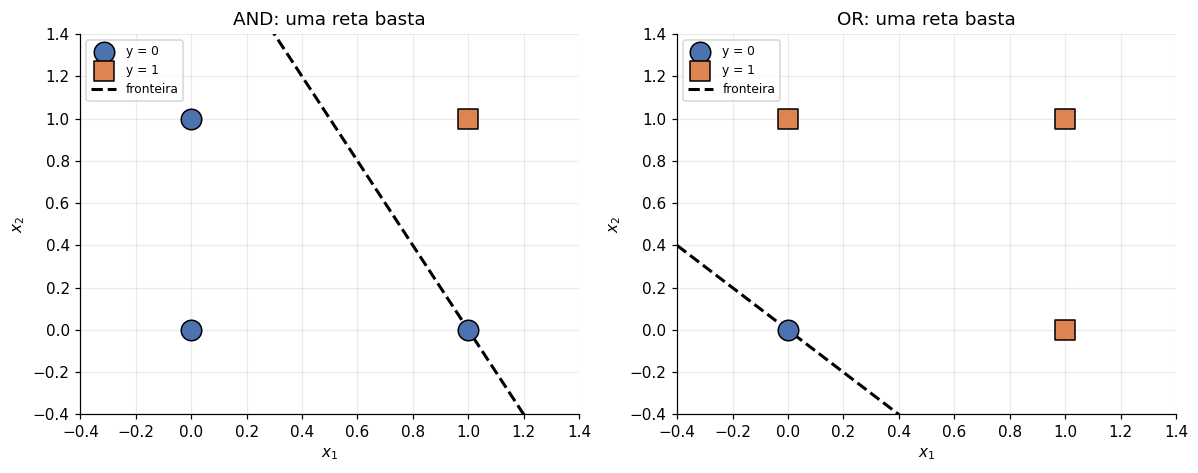

In [16]:
def desenha_fronteira_logica(theta, y_alvo, titulo, ax):
    """Desenha os 4 pontos lógicos e a reta theta0 + theta1·x1 + theta2·x2 = 0."""
    for classe, marcador in [(0, "o"), (1, "s")]:
        m = y_alvo == classe
        ax.scatter(X_LOGICO[m, 0], X_LOGICO[m, 1], s=180, marker=marcador,
                   color=CORES[classe], edgecolor="black", zorder=3,
                   label=f"y = {classe}")
    if abs(theta[2]) > 1e-9:
        xs = np.linspace(-0.4, 1.4, 50)
        ax.plot(xs, -(theta[0] + theta[1] * xs) / theta[2], color="black",
                lw=2, ls="--", label="fronteira")
    ax.set_xlim(-0.4, 1.4)
    ax.set_ylim(-0.4, 1.4)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(titulo)
    ax.legend(fontsize=8, loc="upper left")


fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
desenha_fronteira_logica(theta_and, y_and, "AND: uma reta basta", axes[0])
desenha_fronteira_logica(theta_or, y_or, "OR: uma reta basta", axes[1])
plt.tight_layout()
plt.show()

---
## 4. Onde o perceptron trava: o XOR

🔎 **PARE E PENSE**: no XOR os positivos são $(0,1)$ e $(1,0)$ - dois cantos
**opostos** do quadrado. Antes de rodar: existe reta que deixe esses dois de um lado
e $(0,0)$ e $(1,1)$ do outro? E o que o algoritmo vai fazer se não existir - parar,
avisar, ou ficar mexendo nos pesos para sempre?

XOR, alpha = 0,5, 20 ciclos:
  ciclo 1: 2 atualização(ões), theta = [ 0.  -0.5  0. ]
  ciclo 2: 3 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 3: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 4: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 5: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 6: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 7: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 8: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 9: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 10: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 11: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 12: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 13: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 14: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 15: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 16: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 17: 4 atualização(ões), theta = [ 0.5 -0.5  0. ]
  ciclo 18:

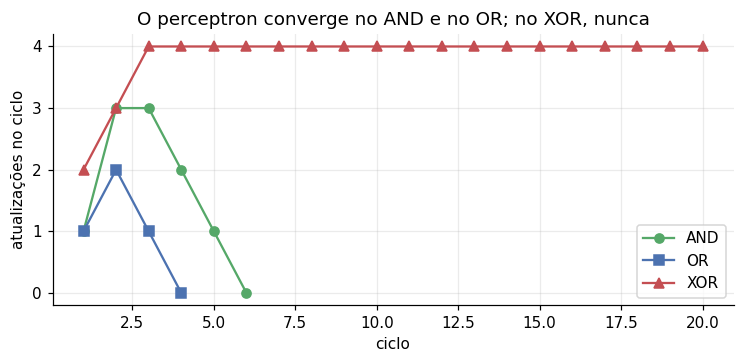


Acurácia do perceptron no XOR: 50%  (chutar sempre 0 dá 50%)


In [17]:
print("XOR, alpha = 0,5, 20 ciclos:")
theta_xor, erros_xor = treina_perceptron(X_LOGICO, y_xor, alpha=0.5, epocas=20, verbose=True)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(range(1, len(erros_and) + 1), erros_and, "o-", color=CORES[2], label="AND")
ax.plot(range(1, len(erros_or) + 1), erros_or, "s-", color=CORES[0], label="OR")
ax.plot(range(1, len(erros_xor) + 1), erros_xor, "^-", color=CORES[3], label="XOR")
ax.set_xlabel("ciclo")
ax.set_ylabel("atualizações no ciclo")
ax.set_title("O perceptron converge no AND e no OR; no XOR, nunca")
ax.legend()
plt.tight_layout()
plt.show()

acertos_xor = (degrau(com_bias(X_LOGICO) @ theta_xor) == y_xor).mean()
print(f"\nAcurácia do perceptron no XOR: {acertos_xor:.0%}  (chutar sempre 0 dá 50%)")

🎯 O algoritmo **não avisa** que o problema é impossível: ele fica corrigindo para
sempre, em ciclo. Esse é o ponto do slide 26 - *a regra de treinamento do perceptron
não converge quando o problema não é linearmente separável*. E não é um caso
patológico de laboratório: o XOR é a operação "um ou outro, mas não os dois", que
aparece o tempo todo em dados reais.

---
## 5. Regra delta, unidade linear, unidade sigmoide

A primeira reação histórica ao problema foi trocar a regra de aprendizado. Em vez de
corrigir os pesos **exemplo a exemplo**, a **regra delta** (ou Widrow-Hoff, ou LMS)
soma o erro de todos os exemplos e só então atualiza:

$$\theta_j := \theta_j + \alpha \sum_{i=1}^{m}\left(y^{(i)} - h(x^{(i)})\right) x_j^{(i)}$$

Você já viu essa fórmula: é o gradiente descendente **em lote** da aula 02, com o
sinal escrito do outro jeito. E ela exige algo que o perceptron não tem: para falar
em gradiente, a ativação precisa ser **derivável**. Sem o degrau, a unidade deixa de
se chamar perceptron e passa a se chamar **unidade linear**; com a sigmoide no lugar
dele, vira a **unidade sigmoide** - que é, literalmente, o regressor logístico da
seção 1.

In [18]:
print("As três atualizações, lado a lado:\n")
print("  perceptron    theta_j += alpha · (y - h) · x_j        para CADA exemplo, na hora")
print("  regra delta   theta_j += alpha · Σ (y - h) · x_j      uma vez por passada")
print("  logística     theta_j -= alpha · (1/m) Σ (h - y) · x_j    (a mesma coisa)\n")
print("A diferença real não está na fórmula, está na ATIVAÇÃO:")
print("  degrau   -> não derivável -> só a regra do perceptron")
print("  sigmoide -> derivável     -> gradiente descendente, e o custo vira entropia cruzada")

As três atualizações, lado a lado:

  perceptron    theta_j += alpha · (y - h) · x_j        para CADA exemplo, na hora
  regra delta   theta_j += alpha · Σ (y - h) · x_j      uma vez por passada
  logística     theta_j -= alpha · (1/m) Σ (h - y) · x_j    (a mesma coisa)

A diferença real não está na fórmula, está na ATIVAÇÃO:
  degrau   -> não derivável -> só a regra do perceptron
  sigmoide -> derivável     -> gradiente descendente, e o custo vira entropia cruzada


Só que trocar o degrau pela sigmoide **não resolve o XOR**. A fronteira da unidade
sigmoide continua sendo $\theta^T x = 0$, continua sendo uma reta. Mudou a suavidade,
não a forma.

In [19]:
from sklearn.linear_model import LogisticRegression

log_xor = LogisticRegression(C=1e6, max_iter=10000).fit(X_LOGICO, y_xor)
print(f"Regressão logística no XOR: acurácia {log_xor.score(X_LOGICO, y_xor):.0%}")
print(f"probabilidades: {log_xor.predict_proba(X_LOGICO)[:, 1].round(3)}")
print("\nTodas as quatro em 0,5: o modelo empatou em tudo. Nenhuma reta serve.")

Regressão logística no XOR: acurácia 50%
probabilidades: [0.5 0.5 0.5 0.5]

Todas as quatro em 0,5: o modelo empatou em tudo. Nenhuma reta serve.


---
## 6. Duas saídas para o não linear

A aula 03 já mostrou a primeira: **termos polinomiais**. Funcionou lindamente no
XOR e nos círculos. O problema aparece quando há muitos atributos, porque o número de
termos explode.

In [20]:
from math import comb

print("Quantos termos tem um polinômio completo, por número de atributos:\n")
print(f"{'atributos':>10} {'grau 2':>12} {'grau 3':>12}")
for n in [2, 4, 10, 50, 100]:
    print(f"{n:>10} {comb(n + 2, 2) - 1:>12,} {comb(n + 3, 3) - 1:>12,}".replace(",", "."))

print("\nÉ o cálculo do slide 31: com n = 100 atributos, o grau 2 já pede ~5.000 termos")
print("e o grau 3, ~177.000. Uma imagem 28x28 tem n = 784 atributos.")
print(f"Grau 2 numa imagem 28x28: {comb(784 + 2, 2) - 1:,} termos.".replace(",", "."))

Quantos termos tem um polinômio completo, por número de atributos:

 atributos       grau 2       grau 3
         2            5            9
         4           14           34
        10           65          285
        50        1.325       23.425
       100        5.150      176.850

É o cálculo do slide 31: com n = 100 atributos, o grau 2 já pede ~5.000 termos
e o grau 3, ~177.000. Uma imagem 28x28 tem n = 784 atributos.
Grau 2 numa imagem 28x28: 308.504 termos.


In [21]:
# Não é conta de guardanapo - dá para verificar com o próprio scikit-learn.
from sklearn.preprocessing import PolynomialFeatures

X_falso = rng.normal(size=(3, 100))
print("PolynomialFeatures(2) sobre 100 atributos:",
      PolynomialFeatures(2, include_bias=False).fit_transform(X_falso).shape[1], "colunas")

PolynomialFeatures(2) sobre 100 atributos: 5150 colunas


A segunda saída é a das redes neurais: em vez de uma hipótese mais complicada,
**várias hipóteses simples, em camadas**. O custo cresce com o número de unidades, que
a gente escolhe - e não com o número de atributos elevado ao grau, que a gente não
escolhe.

---
## 7. A arquitetura da rede

```
   x1 ──┐   ┌── a1 ──┐
   x2 ──┼──►├── a2 ──┼──►  hΘ(x)
   x3 ──┘   └── a3 ──┘

   L1          L2         L3
 entrada    escondida    saída
```

Cada camada é um **conjunto de unidades sigmoides** como a da seção 1, todas olhando
para a mesma entrada, cada uma com seu próprio vetor de pesos. Guardar esses vetores
um do lado do outro dá uma **matriz**:

- $a_i^{(j)}$ é a ativação (a saída) da unidade $i$ na camada $j$;
- $\Theta^{(j)}$ é a matriz que liga a camada $j$ à camada $j+1$.

A regra de dimensões do slide 34: se a camada $j$ tem $s_j$ unidades e a camada $j+1$
tem $s_{j+1}$, então $\Theta^{(j)}$ tem $s_j + 1$ linhas (o $+1$ é o bias) e
$s_{j+1}$ colunas.

In [22]:
def dimensoes(camadas):
    """Dimensões das matrizes Theta de uma rede, dada a lista de tamanhos das camadas."""
    linhas = []
    total = 0
    for j, (s_atual, s_prox) in enumerate(zip(camadas, camadas[1:]), start=1):
        n_par = (s_atual + 1) * s_prox
        total += n_par
        linhas.append({
            "matriz": f"Theta^({j})",
            "liga": f"L{j} -> L{j+1}",
            "formato": f"({s_atual} + 1) x {s_prox}",
            "parâmetros": n_par,
        })
    tab = pd.DataFrame(linhas)
    print(tab.to_string(index=False))
    print(f"{'':>34}total: {total}")
    return total


print("Rede do slide 35/36 - 3 entradas, 3 escondidas, 1 saída:")
dimensoes([3, 3, 1])
print("\nRede do slide 40 - 3 entradas, duas camadas escondidas de 2, 1 saída:")
dimensoes([3, 2, 2, 1])
print("\nA rede que vamos treinar nos dígitos (64 pixels, 30 escondidas, 10 classes):")
dimensoes([64, 30, 10])

Rede do slide 35/36 - 3 entradas, 3 escondidas, 1 saída:
   matriz     liga     formato  parâmetros
Theta^(1) L1 -> L2 (3 + 1) x 3          12
Theta^(2) L2 -> L3 (3 + 1) x 1           4
                                  total: 16

Rede do slide 40 - 3 entradas, duas camadas escondidas de 2, 1 saída:
   matriz     liga     formato  parâmetros
Theta^(1) L1 -> L2 (3 + 1) x 2           8
Theta^(2) L2 -> L3 (2 + 1) x 2           6
Theta^(3) L3 -> L4 (2 + 1) x 1           3
                                  total: 17

A rede que vamos treinar nos dígitos (64 pixels, 30 escondidas, 10 classes):
   matriz     liga       formato  parâmetros
Theta^(1) L1 -> L2 (64 + 1) x 30        1950
Theta^(2) L2 -> L3 (30 + 1) x 10         310
                                  total: 2260


2260

---
## 8. Forward propagation

Calcular a saída da rede é propagar os sinais da entrada para a saída, camada a
camada. Para cada camada: acrescente o bias, multiplique pela matriz $\Theta$, aplique
a sigmoide. Repita.

$$a^{(1)} = x \quad\longrightarrow\quad
  a^{(j+1)} = g\left(\left[1\ ;\ a^{(j)}\right] \Theta^{(j)}\right)$$

Escrito assim, com matrizes, o cálculo vale para a base inteira de uma vez - é o
*implementation trick* do slide 37.

### 🔨 IMPLEMENTE 4 - a propagação para frente

In [23]:
def forward(X, thetas):
    """Propaga X pela rede e devolve as ativações de todas as camadas.

    Parâmetros
    ----------
    X      : np.ndarray (m, n) - os atributos, SEM bias
    thetas : lista de matrizes; thetas[j] tem formato (s_j + 1, s_{j+1})

    Devolve
    -------
    lista de np.ndarray: [a^(1), a^(2), ..., a^(L)], todas SEM a coluna de bias.
    A última é a saída da rede.
    """
    ativacoes = [np.asarray(X, dtype=float)]
    for Theta in thetas:
        anterior = ativacoes[-1]
        ativacoes.append(sigmoide(com_bias(anterior) @ Theta))
    return ativacoes

### As três portas lógicas dos slides

Antes de montar a rede inteira, confira as unidades isoladas dos slides 43 a 47. Os
pesos foram **escolhidos à mão**, não aprendidos - a ideia é convencer que uma única
unidade sigmoide já computa AND, OR e NOT.

O truque dos números grandes: $g(10) \approx 0{,}99996$ e $g(-10) \approx 0{,}00005$.
Com pesos da ordem de 20, a sigmoide fica praticamente saturada e a unidade se
comporta como um degrau.

In [24]:
PORTAS = {
    "AND            (slide 44)": np.array([[-30.0], [20.0], [20.0]]),
    "OR             (slide 45)": np.array([[-10.0], [20.0], [20.0]]),
    "(NOT x1) AND (NOT x2)  (slide 47)": np.array([[10.0], [-20.0], [-20.0]]),
}
for nome, Theta in PORTAS.items():
    saida = forward(X_LOGICO, [Theta])[-1].ravel()
    print(f"{nome}:  {np.round(saida, 4)}   ->  {saida.round().astype(int)}")

assert np.allclose(forward(X_LOGICO, [PORTAS["AND            (slide 44)"]])[-1].ravel().round(), y_and)
assert np.allclose(forward(X_LOGICO, [PORTAS["OR             (slide 45)"]])[-1].ravel().round(), y_or)
print("\nOK - uma unidade sigmoide computa AND e OR com os pesos do slide.")

AND            (slide 44):  [0. 0. 0. 1.]   ->  [0 0 0 1]
OR             (slide 45):  [0. 1. 1. 1.]   ->  [0 1 1 1]
(NOT x1) AND (NOT x2)  (slide 47):  [1. 0. 0. 0.]   ->  [1 0 0 0]

OK - uma unidade sigmoide computa AND e OR com os pesos do slide.


### A rede XNOR do slide 49

Agora a montagem. O XNOR ("iguais") é verdadeiro em $(0,0)$ e $(1,1)$. Os slides
resolvem assim:

- a primeira unidade escondida calcula $x_1 \text{ AND } x_2$ - liga em $(1,1)$;
- a segunda calcula $(\text{NOT } x_1) \text{ AND } (\text{NOT } x_2)$ - liga em $(0,0)$;
- a unidade de saída calcula o **OR** das duas.

As duas primeiras viram as colunas de $\Theta^{(1)}$; a terceira é $\Theta^{(2)}$.

In [25]:
THETA1_XNOR = np.array([
    [-30.0,  10.0],    # bias:   AND,  NOT-NOT
    [ 20.0, -20.0],    # x1
    [ 20.0, -20.0],    # x2
])
THETA2_XNOR = np.array([[-10.0], [20.0], [20.0]])   # OR das duas escondidas

ativacoes = forward(X_LOGICO, [THETA1_XNOR, THETA2_XNOR])
A2, H = ativacoes[1], ativacoes[2].ravel()

tabela = pd.DataFrame({
    "x1": X_LOGICO[:, 0].astype(int),
    "x2": X_LOGICO[:, 1].astype(int),
    "a1 (AND)": A2[:, 0].round(4),
    "a2 (NOT e NOT)": A2[:, 1].round(4),
    "h(x)": H.round(4),
    "XNOR esperado": [1, 0, 0, 1],
})
print(tabela.to_string(index=False))

 x1  x2  a1 (AND)  a2 (NOT e NOT)  h(x)  XNOR esperado
  0   0       0.0             1.0   1.0              1
  0   1       0.0             0.0   0.0              0
  1   0       0.0             0.0   0.0              0
  1   1       1.0             0.0   1.0              1


In [26]:
# Conferência da IMPLEMENTE 4: a tabela verdade do slide 49.
assert [a.shape for a in ativacoes] == [(4, 2), (4, 2), (4, 1)], \
    "as ativações devem ter formatos (4,2), (4,2) e (4,1)"
assert np.array_equal(H.round(), np.array([1.0, 0.0, 0.0, 1.0])), \
    f"a rede deveria computar o XNOR [1, 0, 0, 1]; veio {H.round()}"
assert np.allclose(A2.round(), [[0, 1], [0, 0], [0, 0], [1, 0]]), \
    "as ativações escondidas deveriam ser as do slide 49"
print("OK - a rede de três unidades computa o XNOR.")
print("\nRepare na coluna do meio: nenhuma das duas unidades escondidas sozinha resolve")
print("o problema. A de cima só reconhece (1,1); a de baixo só reconhece (0,0). Quem")
print("junta as duas é a camada de saída - com um simples OR.")

OK - a rede de três unidades computa o XNOR.

Repare na coluna do meio: nenhuma das duas unidades escondidas sozinha resolve
o problema. A de cima só reconhece (1,1); a de baixo só reconhece (0,0). Quem
junta as duas é a camada de saída - com um simples OR.


🔎 **PARE E PENSE**: a rede tem 9 parâmetros e resolve um problema que **nenhuma**
reta resolve. Mas note o que aconteceu com o espaço: a camada escondida transformou
$(x_1, x_2)$ em $(a_1, a_2)$. Nesse novo par de coordenadas, o problema virou um OR -
e OR, nós já sabemos, se resolve com uma reta. Desenhe os quatro pontos no plano
$(a_1, a_2)$ antes de rodar a célula abaixo.

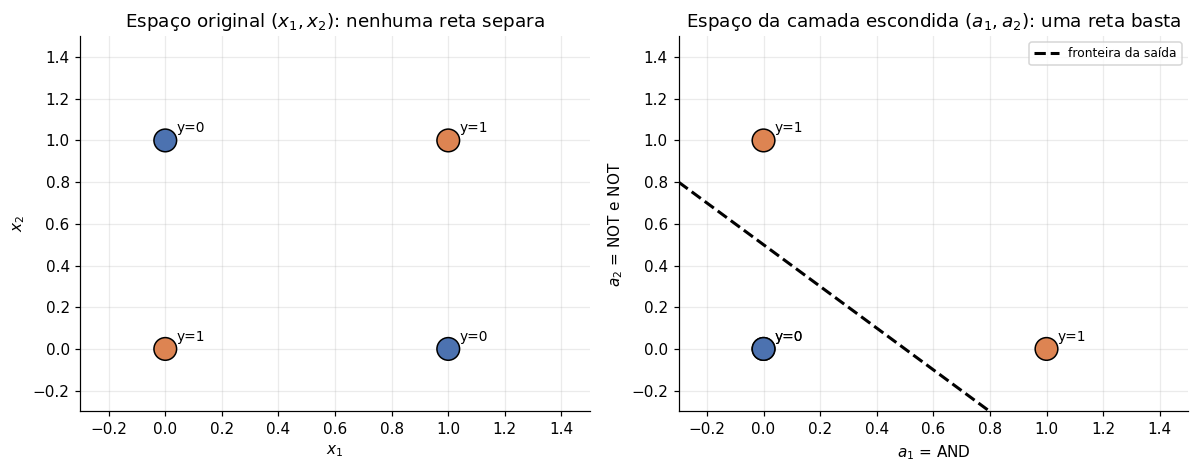

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
cores_pt = [CORES[int(v)] for v in [1, 0, 0, 1]]
axes[0].scatter(X_LOGICO[:, 0], X_LOGICO[:, 1], s=220, c=cores_pt,
                edgecolor="black", zorder=3)
for xi, rot in zip(X_LOGICO, [1, 0, 0, 1]):
    axes[0].annotate(f"y={rot}", xi + 0.04, fontsize=9)
axes[0].set_title("Espaço original $(x_1, x_2)$: nenhuma reta separa")
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$")
axes[0].set_xlim(-0.3, 1.5); axes[0].set_ylim(-0.3, 1.5)

axes[1].scatter(A2[:, 0], A2[:, 1], s=220, c=cores_pt, edgecolor="black", zorder=3)
for ai, rot in zip(A2, [1, 0, 0, 1]):
    axes[1].annotate(f"y={rot}", ai + 0.04, fontsize=9)
linha = np.linspace(-0.3, 1.5, 20)
axes[1].plot(linha, 0.5 - linha, ls="--", color="black", lw=2, label="fronteira da saída")
axes[1].set_title("Espaço da camada escondida $(a_1, a_2)$: uma reta basta")
axes[1].set_xlabel("$a_1$ = AND"); axes[1].set_ylabel("$a_2$ = NOT e NOT")
axes[1].set_xlim(-0.3, 1.5); axes[1].set_ylim(-0.3, 1.5)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

🎯 Essa é a ideia central da aula, e vale repetir: **a camada escondida não
classifica, ela muda de coordenadas**. Ela reescreve cada exemplo em termos de
atributos novos, escolhidos de modo que o problema fique fácil para a camada seguinte.
A última camada é sempre uma regressão logística comum - só que aplicada a atributos
que a própria rede inventou.

---
## 9. A rede inventa seus próprios atributos

Na seção 8 os pesos vieram do slide. Agora vamos deixar a rede **aprender** e ver se
ela descobre sozinha uma transformação parecida.

Os quatro pontos do XOR são poucos demais para treinar, então espalhamos uma nuvem em
volta de cada canto - 240 exemplos, mesma lógica de rótulo. É o XOR "com dados".

In [28]:
centros = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
rotulos = np.array([0, 1, 1, 0])

X_nuvem = np.vstack([rng.normal(c, 0.14, size=(60, 2)) for c in centros])
y_nuvem = np.concatenate([np.full(60, r) for r in rotulos])
print(f"{len(y_nuvem)} exemplos, {int(y_nuvem.sum())} da classe 1")

240 exemplos, 120 da classe 1


In [29]:
from sklearn.neural_network import MLPClassifier

rede = MLPClassifier(
    hidden_layer_sizes=(2,),      # UMA camada escondida, com DUAS unidades
    activation="logistic",        # a sigmoide da aula toda
    solver="lbfgs",               # ótimo para bases pequenas
    max_iter=5000,
    random_state=RANDOM_STATE,
).fit(X_nuvem, y_nuvem)

print(f"Acurácia no treino: {rede.score(X_nuvem, y_nuvem):.2%}")
print(f"Formato dos pesos aprendidos: {[c.shape for c in rede.coefs_]}")
print(f"Formato dos bias:             {[b.shape for b in rede.intercepts_]}")
print("\n(O scikit-learn guarda o bias separado; nas nossas contas ele era a 1ª linha de Theta.)")

Acurácia no treino: 98.75%
Formato dos pesos aprendidos: [(2, 2), (2, 1)]
Formato dos bias:             [(2,), (1,)]

(O scikit-learn guarda o bias separado; nas nossas contas ele era a 1ª linha de Theta.)


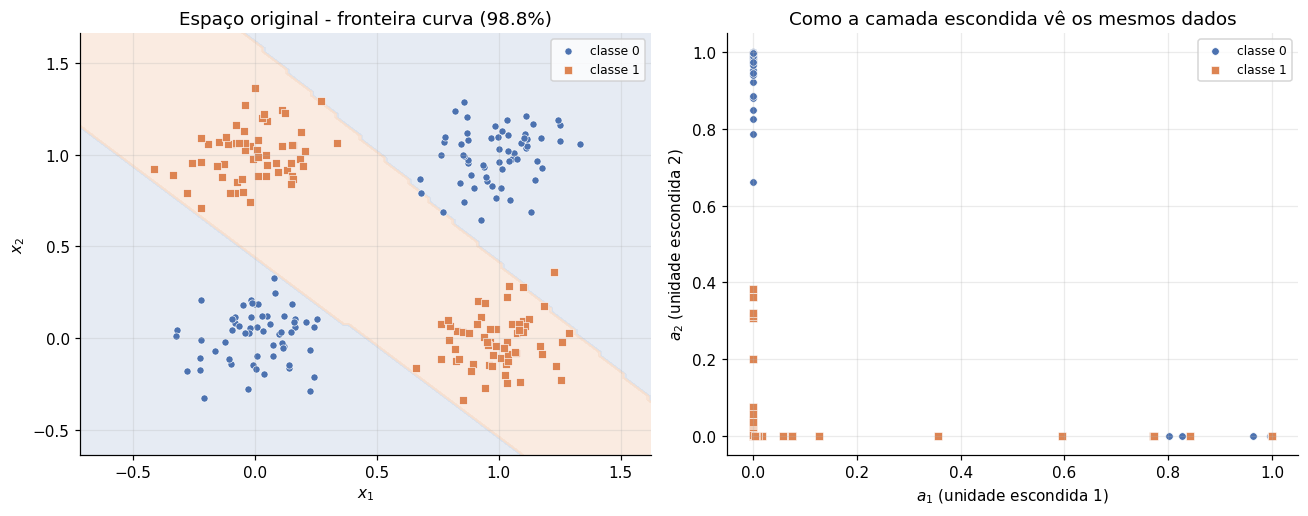

In [30]:
def plota_regioes(modelo, X, y, ax, titulo=""):
    """Pinta as regiões de decisão de um modelo qualquer sobre uma grade 2D."""
    passo = 0.02
    x1 = np.arange(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, passo)
    x2 = np.arange(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, passo)
    G1, G2 = np.meshgrid(x1, x2)
    Z = modelo.predict(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape)
    ax.contourf(G1, G2, Z, alpha=0.6, cmap=MAPA_REGIOES)
    for classe, marcador in [(0, "o"), (1, "s")]:
        m = y == classe
        ax.scatter(X[m, 0], X[m, 1], s=22, marker=marcador, color=CORES[classe],
                   edgecolor="white", linewidth=0.4, label=f"classe {classe}")
    ax.set_title(titulo)
    ax.legend(fontsize=8, loc="upper right")


# As ativações da camada escondida, na mão - é a nossa forward, com os pesos treinados.
A_escondida = sigmoide(X_nuvem @ rede.coefs_[0] + rede.intercepts_[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plota_regioes(rede, X_nuvem, y_nuvem, axes[0],
              f"Espaço original - fronteira curva ({rede.score(X_nuvem, y_nuvem):.1%})")
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$")

for classe, marcador in [(0, "o"), (1, "s")]:
    m = y_nuvem == classe
    axes[1].scatter(A_escondida[m, 0], A_escondida[m, 1], s=24, marker=marcador,
                    color=CORES[classe], edgecolor="white", linewidth=0.4,
                    label=f"classe {classe}")
axes[1].set_xlabel("$a_1$ (unidade escondida 1)")
axes[1].set_ylabel("$a_2$ (unidade escondida 2)")
axes[1].set_title("Como a camada escondida vê os mesmos dados")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

🔎 **PARE E PENSE**: à esquerda, a fronteira é uma curva fechada que nenhuma reta
imitaria. À direita, os mesmos exemplos, nas coordenadas inventadas pela rede:
os grupos foram empurrados para cantos distintos do quadrado, e agora **uma reta
separa**. A rede não aprendeu uma fronteira complicada - ela aprendeu um sistema de
coordenadas em que a fronteira é simples.

---
## 10. Backpropagation

Falta a pergunta que ficou pendurada: como se acha $\Theta$?

Pelo gradiente descendente - o mesmo da seção 1 e da aula 02. O problema é calcular
$\partial J / \partial \Theta^{(l)}_{ij}$ quando o parâmetro está lá no fundo, a duas
ou três camadas da saída. O **backpropagation** resolve isso com duas passadas:

- **forward**: propaga as ativações da entrada até a saída (nossa seção 8);
- **backward**: propaga o **erro** da saída de volta até a entrada, distribuindo a
  culpa. O erro da camada de saída é $\delta^{(L)} = h_\Theta(x) - y$; o de uma camada
  escondida é o erro da camada seguinte, puxado de volta pelos pesos que os ligam e
  multiplicado pela derivada da ativação ali,
  $\delta^{(l)} = \left(\delta^{(l+1)}\,\Theta^{(l)\,T}\right) \odot a^{(l)}(1 - a^{(l)})$.

A intuição dos slides 53 a 63 é essa: **uma unidade escondida é responsável pelo erro
final na proporção do peso com que ela contribuiu para ele.**

O código abaixo vem pronto - implementar backpropagation à mão é assunto para a
disciplina de aprendizado profundo. O que interessa aqui é **conferir** que ele
calcula mesmo a derivada.

In [31]:
def custo_rede(X, y, thetas):
    """Entropia cruzada da saída da rede (uma unidade de saída)."""
    EPS = 1e-12
    h = forward(X, thetas)[-1].ravel()
    return float(-np.mean(y * np.log(h + EPS) + (1 - y) * np.log(1 - h + EPS)))


def backpropagation(X, y, thetas):
    """Gradiente de J em relação a cada matriz Theta. Devolve uma lista de matrizes."""
    m = len(y)
    a = forward(X, thetas)                      # a[0] = entrada, a[-1] = saída
    delta = a[-1] - y.reshape(-1, 1)            # erro na camada de saída
    gradientes = [None] * len(thetas)

    for l in reversed(range(len(thetas))):
        gradientes[l] = com_bias(a[l]).T @ delta / m
        if l > 0:                               # propaga o erro para a camada anterior
            #        puxa pelos pesos (sem a linha do bias)  ×  derivada da sigmoide
            delta = (delta @ thetas[l][1:].T) * a[l] * (1 - a[l])
    return gradientes


# Uma rede 2-2-1 com pesos aleatórios, sobre os quatro pontos do XOR.
gerador = np.random.default_rng(1)
thetas_teste = [gerador.normal(0, 1, (3, 2)), gerador.normal(0, 1, (3, 1))]
grad_backprop = backpropagation(X_LOGICO, y_xor, thetas_teste)

# Verificação numérica: a mesma técnica da aula 02, agora parâmetro a parâmetro.
EPS = 1e-5
maior_diferenca = 0.0
for l, Theta in enumerate(thetas_teste):
    for i in range(Theta.shape[0]):
        for j in range(Theta.shape[1]):
            mais, menos = [t.copy() for t in thetas_teste], [t.copy() for t in thetas_teste]
            mais[l][i, j] += EPS
            menos[l][i, j] -= EPS
            numerico = (custo_rede(X_LOGICO, y_xor, mais)
                        - custo_rede(X_LOGICO, y_xor, menos)) / (2 * EPS)
            maior_diferenca = max(maior_diferenca, abs(numerico - grad_backprop[l][i, j]))

assert maior_diferenca < 1e-8, f"backpropagation e derivada numérica discordam em {maior_diferenca}"
print(f"OK - a maior discordância entre backpropagation e diferenças centrais foi "
      f"{maior_diferenca:.2e}.")
print("\nOu seja: as duas passadas realmente calculam a derivada da função de custo.")
print("O que backpropagation economiza é TEMPO - a verificação numérica acima precisou")
print(f"de {2 * sum(t.size for t in thetas_teste)} avaliações do custo para 9 parâmetros;")
print("backpropagation faz tudo com uma passada para frente e uma para trás.")

OK - a maior discordância entre backpropagation e diferenças centrais foi 8.44e-12.

Ou seja: as duas passadas realmente calculam a derivada da função de custo.
O que backpropagation economiza é TEMPO - a verificação numérica acima precisou
de 18 avaliações do custo para 9 parâmetros;
backpropagation faz tudo com uma passada para frente e uma para trás.


### Treinando com o gradiente que acabamos de conferir

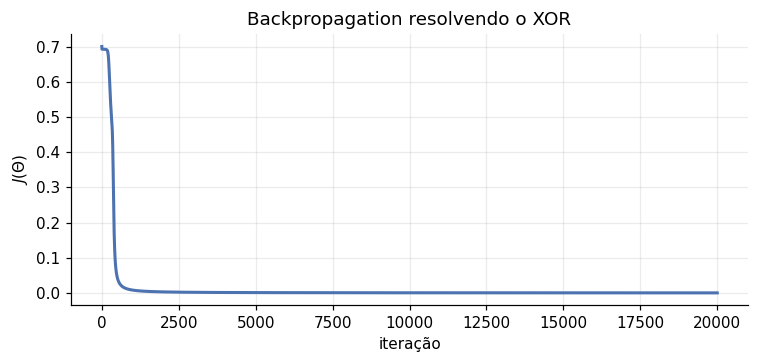

saída da rede: [0. 1. 1. 0.]   alvo: [0 1 1 0]

OK - a mesma rede que o perceptron não conseguia treinar, agora treinada.
Compare com a seção 4: lá, o erro nunca chegava a zero.


In [32]:
thetas = [gerador.normal(0, 0.5, (3, 2)), gerador.normal(0, 0.5, (3, 1))]
alpha = 2.0
historico_rede = []
for passo in range(20000):
    historico_rede.append(custo_rede(X_LOGICO, y_xor, thetas))
    grads = backpropagation(X_LOGICO, y_xor, thetas)
    thetas = [T - alpha * G for T, G in zip(thetas, grads)]

saida_final = forward(X_LOGICO, thetas)[-1].ravel()

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(historico_rede, color=CORES[0], lw=2)
ax.set_xlabel("iteração")
ax.set_ylabel(r"$J(\Theta)$")
ax.set_title("Backpropagation resolvendo o XOR")
plt.tight_layout()
plt.show()

print(f"saída da rede: {saida_final.round(3)}   alvo: {y_xor.astype(int)}")
assert np.array_equal(saida_final.round(), y_xor), "a rede treinada deveria acertar o XOR"
print("\nOK - a mesma rede que o perceptron não conseguia treinar, agora treinada.")
print("Compare com a seção 4: lá, o erro nunca chegava a zero.")

🔎 **PARE E PENSE**: a curva acima costuma ficar num platô por algumas centenas de
iterações antes de despencar. O que estava acontecendo nesse trecho plano? (Dica:
lembre da seção 1 - a rede também tem regiões quase planas no custo, e com **várias
camadas** o custo deixa de ser convexo. Onde o treino termina passa a depender de
**onde ele começou**. Por isso o `random_state` importa numa rede e não importava numa
regressão logística - e por isso o exercício 2 desta aula existe.)

---
## 11. Mais de duas classes: reconhecendo dígitos

Até aqui, uma unidade na saída: $h(x)$ perto de 1 ou perto de 0. Para $K$ classes, a
solução do slide 51 é **um neurônio de saída por classe**, e o rótulo deixa de ser um
número e vira um **vetor**:

$$y = [1, 0, 0, \dots] \text{ para a classe 1}, \quad
  y = [0, 1, 0, \dots] \text{ para a classe 2}, \quad \dots$$

Essa codificação tem nome: *one-hot*. A rede devolve $K$ números e a classe predita é
a do neurônio que acendeu mais forte.

A base: **Digits**, 1.797 imagens de 8×8 pixels em tons de cinza (0 a 16), cada uma um
algarismo escrito à mão. Vem junto com o scikit-learn, então não precisa de download.

- **Referência:** ALPAYDIN, E.; KAYNAK, C. *Optical Recognition of Handwritten Digits*.
  UCI Machine Learning Repository, 1998.

1797 imagens de 64 pixels (8 x 8), 10 classes


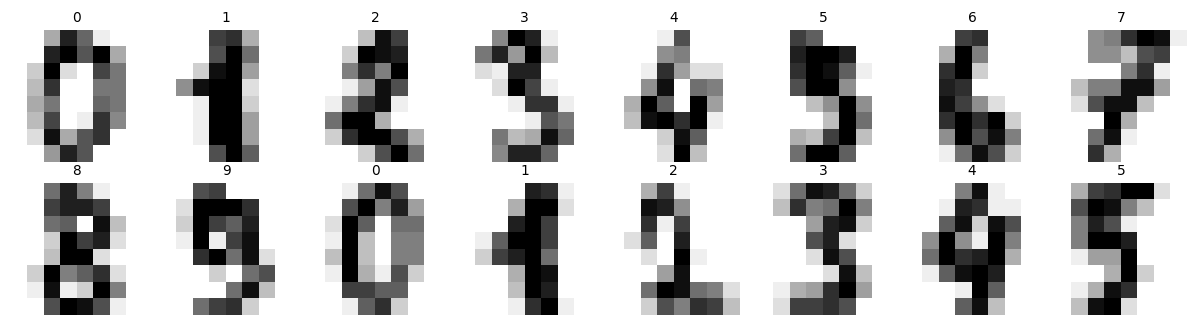

In [33]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

digitos = load_digits()
X_dig, y_dig = digitos.data, digitos.target
print(f"{X_dig.shape[0]} imagens de {X_dig.shape[1]} pixels (8 x 8), "
      f"{len(np.unique(y_dig))} classes")

fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for ax, imagem, alvo in zip(axes.ravel(), digitos.images, y_dig):
    ax.imshow(imagem, cmap="gray_r")
    ax.set_title(str(alvo), fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [34]:
# Como a rede enxerga o rótulo: um vetor de 10 posições.
exemplo = 7
one_hot = np.zeros(10, dtype=int)
one_hot[y_dig[exemplo]] = 1
print(f"rótulo do exemplo {exemplo}: {y_dig[exemplo]}")
print(f"o que a camada de saída persegue: {one_hot}")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_dig, y_dig, test_size=0.25, random_state=RANDOM_STATE, stratify=y_dig)
print(f"\ntreino: {len(y_tr)}   teste: {len(y_te)}")

rótulo do exemplo 7: 7
o que a camada de saída persegue: [0 0 0 0 0 0 0 1 0 0]

treino: 1347   teste: 450


Arquitetura: 64 pixels -> 30 unidades escondidas -> 10 saídas
Parâmetros:  2.260
Iterações até convergir: 435

Acurácia no treino: 100.00%
Acurácia no teste:  97.78%


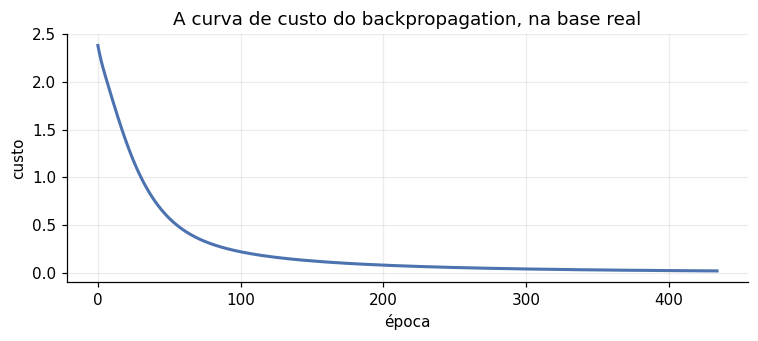

In [35]:
rede_dig = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(30,),     # 64 -> 30 -> 10
        activation="logistic",
        max_iter=600,
        random_state=RANDOM_STATE,
    ),
).fit(X_tr, y_tr)

mlp = rede_dig[-1]
print(f"Arquitetura: 64 pixels -> 30 unidades escondidas -> {mlp.n_outputs_} saídas")
print(f"Parâmetros:  {sum(c.size for c in mlp.coefs_) + sum(b.size for b in mlp.intercepts_):,}"
      .replace(",", "."))
print(f"Iterações até convergir: {mlp.n_iter_}")
print(f"\nAcurácia no treino: {rede_dig.score(X_tr, y_tr):.2%}")
print(f"Acurácia no teste:  {rede_dig.score(X_te, y_te):.2%}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(mlp.loss_curve_, color=CORES[0], lw=2)
ax.set_xlabel("época")
ax.set_ylabel("custo")
ax.set_title("A curva de custo do backpropagation, na base real")
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        45
           1      0.900     0.978     0.938        46
           2      0.977     0.977     0.977        44
           3      0.979     1.000     0.989        46
           4      0.978     0.978     0.978        45
           5      1.000     0.978     0.989        46
           6      1.000     0.978     0.989        45
           7      1.000     1.000     1.000        45
           8      1.000     0.884     0.938        43
           9      0.957     1.000     0.978        45

    accuracy                          0.978       450
   macro avg      0.979     0.977     0.978       450
weighted avg      0.979     0.978     0.978       450



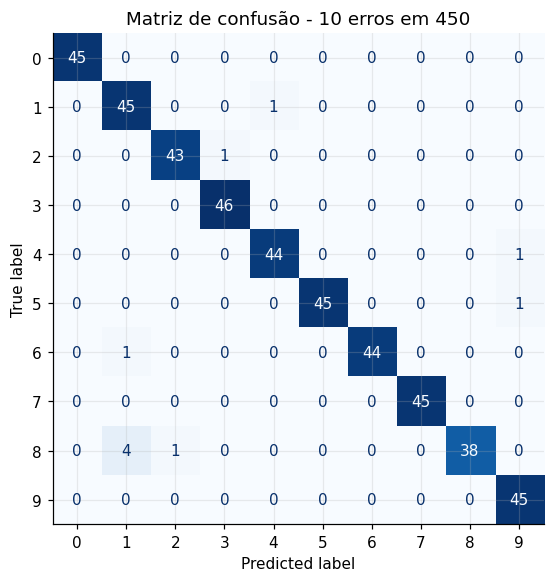

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

pred = rede_dig.predict(X_te)
print(classification_report(y_te, pred, digits=3))

fig, ax = plt.subplots(figsize=(6, 5.4))
ConfusionMatrixDisplay.from_predictions(y_te, pred, ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de confusão - {(pred != y_te).sum()} erros em {len(y_te)}")
plt.tight_layout()
plt.show()

10 erros no conjunto de teste.


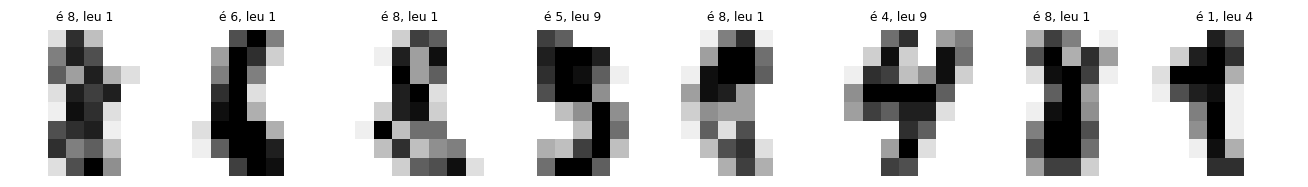

In [37]:
# Os erros, um a um. Em geral são dígitos que um humano também hesitaria em ler.
erradas = np.flatnonzero(pred != y_te)
print(f"{len(erradas)} erros no conjunto de teste.")
n_mostrar = min(len(erradas), 8)
fig, axes = plt.subplots(1, n_mostrar, figsize=(1.5 * n_mostrar, 2.2))
for ax, idx in zip(np.atleast_1d(axes), erradas[:n_mostrar]):
    ax.imshow(X_te[idx].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"é {y_te[idx]}, leu {pred[idx]}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

🔎 **PARE E PENSE**: a acurácia no **treino** é bem maior que a do **teste**. Esse
buraco entre os dois números tem nome - e é o assunto inteiro da próxima aula prática.
Antes de virar a página: ele significa que a rede é grande demais, pequena demais, ou
que os dados é que são poucos? Como você decidiria?

---
# Exercícios

Os três exercícios já vêm com o **código pronto**. O trabalho é rodar, **ler os
resultados** e responder às perguntas nas células de markdown - com frases, não com
números soltos. O exercício 1 usa a **sua** implementação da IMPLEMENTE 3.

## Exercício 1 - os dois exercícios dos slides

Os slides 23 a 25 pedem dois ciclos de treinamento do perceptron, na mão. Aqui você
roda a sua implementação e confere. Comece pelo primeiro: quatro alunos, dois
atributos binários (estudou? fez o trabalho?), e a pergunta é se passou.

| Aluno | Estudou | Fez o trabalho | Passou |
|---|---|---|---|
| Joãozinho | Não | Não | Não |
| Huguinho | Não | Sim | Não |
| Zezinho | Sim | Não | Sim |
| Luizinho | Sim | Sim | Sim |

In [38]:
alunos = pd.DataFrame({
    "aluno": ["Joãozinho", "Huguinho", "Zezinho", "Luizinho"],
    "estudou": [0, 0, 1, 1],
    "trabalho": [0, 1, 0, 1],
    "passou": [0, 0, 1, 1],
})
X_alunos = alunos[["estudou", "trabalho"]].to_numpy(dtype=float)
y_alunos = alunos["passou"].to_numpy(dtype=float)

print("Dois ciclos, alpha = 0,1, pesos iniciais zerados:\n")
theta_alunos, _ = treina_perceptron(X_alunos, y_alunos, alpha=0.1, epocas=2, verbose=True)

previsto = degrau(com_bias(X_alunos) @ theta_alunos)
alunos["h(x)"] = previsto.astype(int)
print("\n" + alunos.to_string(index=False))
print(f"\nAcertos: {int((previsto == y_alunos).sum())} de 4")

Dois ciclos, alpha = 0,1, pesos iniciais zerados:

  ciclo 1: 1 atualização(ões), theta = [0.1 0.1 0. ]
  ciclo 2: 1 atualização(ões), theta = [0.  0.1 0. ]

    aluno  estudou  trabalho  passou  h(x)
Joãozinho        0         0       0     0
 Huguinho        0         1       0     0
  Zezinho        1         0       1     1
 Luizinho        1         1       1     1

Acertos: 4 de 4


Agora o segundo: gripe (1) × resfriado (0), com quatro sintomas.

In [39]:
sintomas = ["virus", "bacteria", "dor_cabeca", "coriza"]
diagnostico = pd.DataFrame(
    [[1, 0, 1, 1, 1], [0, 1, 0, 1, 0], [1, 0, 1, 0, 1],
     [0, 1, 1, 1, 0], [0, 0, 1, 1, 1], [0, 0, 0, 1, 0]],
    columns=sintomas + ["gripe"],
)
X_diag = diagnostico[sintomas].to_numpy(dtype=float)
y_diag = diagnostico["gripe"].to_numpy(dtype=float)
print(diagnostico.to_string(index=False))

print("\nDois ciclos, alpha = 0,1:\n")
theta_diag, erros_diag = treina_perceptron(X_diag, y_diag, alpha=0.1, epocas=2, verbose=True)

print("\nPesos aprendidos:")
for nome, peso in zip(["bias"] + sintomas, theta_diag):
    print(f"  {nome:>12}: {peso:+.1f}")

 virus  bacteria  dor_cabeca  coriza  gripe
     1         0           1       1      1
     0         1           0       1      0
     1         0           1       0      1
     0         1           1       1      0
     0         0           1       1      1
     0         0           0       1      0

Dois ciclos, alpha = 0,1:

  ciclo 1: 2 atualização(ões), theta = [ 0.   0.1 -0.1  0.1  0. ]
  ciclo 2: 0 atualização(ões), theta = [ 0.   0.1 -0.1  0.1  0. ]

Pesos aprendidos:
          bias: +0.0
         virus: +0.1
      bacteria: -0.1
    dor_cabeca: +0.1
        coriza: +0.0


In [40]:
# A segunda parte do slide 25: classificar seis pacientes novos.
novos = pd.DataFrame(
    [[1, 1, 1, 1], [1, 0, 0, 0], [0, 1, 0, 0],
     [0, 1, 1, 1], [1, 0, 0, 1], [0, 0, 0, 0]],
    columns=sintomas,
)
z_novos = com_bias(novos.to_numpy(dtype=float)) @ theta_diag
novos["z = theta^T x"] = z_novos.round(2)
novos["diagnóstico"] = np.where(degrau(z_novos) == 1, "GRIPE", "RESFRIADO")
print(novos.to_string(index=False))

 virus  bacteria  dor_cabeca  coriza  z = theta^T x diagnóstico
     1         1           1       1            0.1       GRIPE
     1         0           0       0            0.1       GRIPE
     0         1           0       0           -0.1   RESFRIADO
     0         1           1       1            0.0   RESFRIADO
     1         0           0       1            0.1       GRIPE
     0         0           0       0            0.0   RESFRIADO


**Responda:**

a) No exercício dos alunos, olhe o $\theta$ final. Qual atributo o perceptron
   considerou relevante e qual ele **ignorou completamente**? Isso faz sentido diante
   da tabela?

b) No exercício do diagnóstico, quantos ciclos o perceptron levou para convergir?
   O que isso diz sobre a separabilidade linear desse problema, comparado ao XOR da
   seção 4?

c) O peso de `coriza` ficou em 0,0. Olhe a coluna `coriza` na tabela de treinamento e
   explique por que **nenhuma** atualização mexeu nesse peso.

d) O primeiro paciente novo tem vírus **e** bactéria ao mesmo tempo - uma combinação
   que não aparece no treinamento. O modelo respondeu mesmo assim. Isso é um problema?
   O que um perceptron faz quando recebe um padrão que nunca viu?

🎯 **Conclusão do Exercício 1**

a) O $\theta$ final é $[0{,}0,\ 0{,}1,\ 0{,}0]$: só o peso de **estudou** sobrou
   diferente de zero. A regra virou "passou = estudou", e o trabalho foi ignorado.
   Faz todo sentido: na tabela, `passou` é **idêntico** a `estudou` nas quatro linhas,
   e o trabalho não muda nada. O perceptron encontrou a regra mais simples que explica
   os dados - uma Navalha de Ockham acidental, obtida sem nenhuma penalização
   explícita por complexidade.

b) Convergiu no **segundo** ciclo (zero atualizações). O problema é linearmente
   separável, e nesse caso o perceptron tem garantia de parar - o teorema da
   convergência. Compare com o XOR: lá o número de atualizações por ciclo se
   estabilizou em 4 e nunca baixou, porque não existe reta para ser encontrada. O
   algoritmo não distingue os dois casos sozinho: quem distingue é quem olha o gráfico.

c) Porque `coriza` vale **1 em todas as seis linhas** de treinamento. A correção é
   $\alpha \cdot E \cdot x_j$, então o peso da coriza recebeu $+0{,}1$ e $-0{,}1$ nas
   duas atualizações do primeiro ciclo (uma com erro positivo, outra com erro
   negativo) e voltou a zero. Um sintoma que **todo mundo** tem não separa ninguém -
   e o algoritmo descobriu isso sozinho. (É o mesmo raciocínio do exercício 1 da aula
   03: atributo sem poder discriminativo ganha coeficiente perto de zero.)

d) O perceptron responde sempre, com a mesma cara de certeza - aqui, GRIPE, porque o
   peso do vírus ($+0{,}1$) empata com o da bactéria ($-0{,}1$) e a dor de cabeça
   ($+0{,}1$) desempata. Ele não tem como dizer "não sei": o degrau devolve 0 ou 1 e
   ponto. É exatamente a limitação que a unidade sigmoide corrige - ela devolveria uma
   **probabilidade**, e um valor perto de 0,5 seria o modelo admitindo dúvida (a
   seção 10 da aula 03). Extrapolar para regiões sem dados de treino é arriscado com
   qualquer modelo; o perigo do degrau é fazer isso sem nenhum sinal de alerta.

## Exercício 2 - quantos neurônios, e por que a semente importa

Na seção 10 a rede resolveu o XOR. Mas na seção 9 apareceu uma frase suspeita: *"o
custo de uma rede não é convexo"*. Quando o custo tem vários vales, **onde o
treinamento começa decide onde ele termina** - e o ponto de partida são os pesos
iniciais aleatórios.

O código abaixo treina o XOR com camadas escondidas de tamanhos diferentes, dez vezes
cada uma, mudando só a semente.

In [41]:
resultados = []
for n_unidades in [1, 2, 3, 4, 8]:
    acuracias = []
    for semente in range(10):
        m = MLPClassifier(hidden_layer_sizes=(n_unidades,), activation="logistic",
                          solver="lbfgs", max_iter=20000, random_state=semente)
        m.fit(X_LOGICO, y_xor)
        acuracias.append(m.score(X_LOGICO, y_xor))
    resultados.append({
        "unidades escondidas": n_unidades,
        "parâmetros": (2 + 1) * n_unidades + (n_unidades + 1),
        "resolveram (de 10)": sum(a == 1.0 for a in acuracias),
        "acurácia média": np.mean(acuracias),
        "pior semente": min(acuracias),
    })

print(pd.DataFrame(resultados).to_string(index=False, float_format=lambda v: f"{v:.2f}"))

 unidades escondidas  parâmetros  resolveram (de 10)  acurácia média  pior semente
                   1           5                   0            0.72          0.50
                   2           9                   5            0.78          0.50
                   3          13                   9            0.95          0.50
                   4          17                  10            1.00          1.00
                   8          33                  10            1.00          1.00


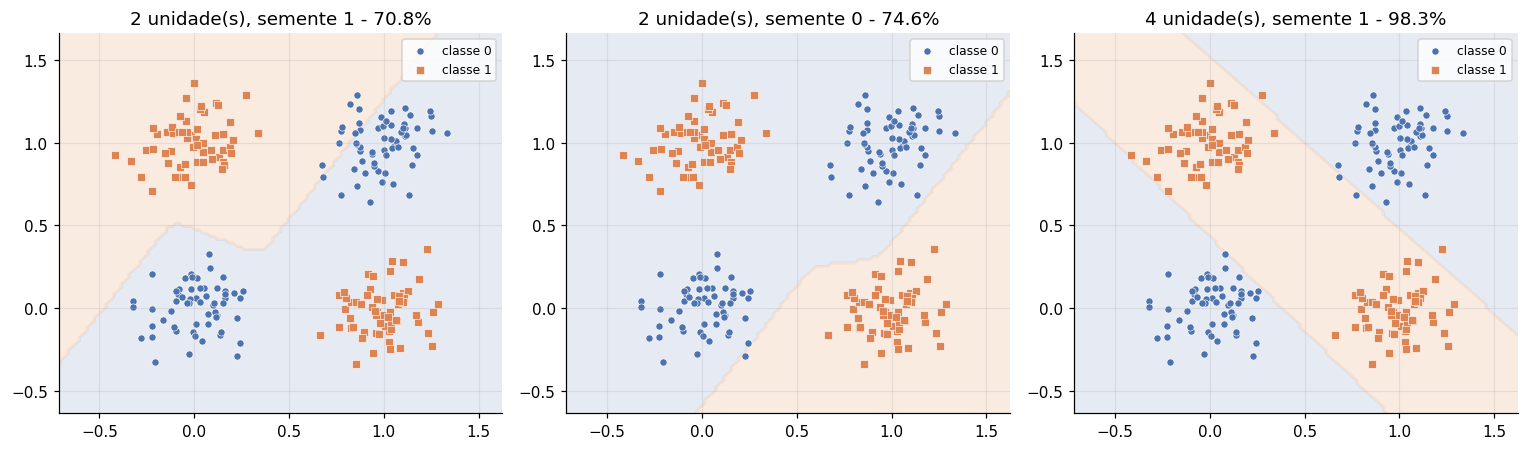

In [42]:
# As fronteiras de duas sementes com DUAS unidades: mesma arquitetura, destinos opostos.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (n_unidades, semente) in zip(axes, [(2, 1), (2, 0), (4, 1)]):
    m = MLPClassifier(hidden_layer_sizes=(n_unidades,), activation="logistic",
                      solver="lbfgs", max_iter=20000, random_state=semente)
    m.fit(X_nuvem, y_nuvem)
    plota_regioes(m, X_nuvem, y_nuvem, ax,
                  f"{n_unidades} unidade(s), semente {semente} - {m.score(X_nuvem, y_nuvem):.1%}")
plt.tight_layout()
plt.show()

**Responda:**

a) Com **uma** unidade escondida, quantas sementes resolveram o XOR? Explique o
   resultado sem falar em sorte - o que uma rede 2-1-1 consegue desenhar?

b) Com **duas** unidades, a mesma arquitetura acerta em algumas sementes e falha em
   outras. Como isso é possível, se os dados e o algoritmo são exatamente os mesmos?

c) A partir de quantas unidades o resultado fica confiável? O que aumentar a camada
   escondida faz, se a rede com duas unidades **já é capaz** de representar o XOR
   (a seção 8 provou isso com 9 parâmetros)?

d) Nos gráficos, compare a fronteira da rede que acertou com a da que falhou. A que
   falhou aprendeu *alguma coisa* ou não aprendeu nada?

🎯 **Conclusão do Exercício 2**

a) **Nenhuma** das dez. E não é azar: uma rede 2-1-1 tem uma só unidade escondida, ou
   seja, ela projeta o plano inteiro num único número $a_1$ antes de decidir. A
   composição de duas funções monótonas de $\theta^T x$ continua tendo fronteira
   linear - a rede é, na prática, uma regressão logística com passos extras. O teto é
   75% (acerta três dos quatro pontos), exatamente o que a tabela mostra.

b) Porque o custo de uma rede com camada escondida **não é convexo**. A inicialização
   aleatória dos pesos escolhe o ponto de partida do gradiente descendente, e pontos
   de partida diferentes escorregam para vales diferentes. Nas sementes que deram 50%,
   o treino parou num mínimo local em que uma das duas unidades ficou inútil. Compare
   com a seção 1: lá, qualquer inicialização levava ao mesmo $\theta$, porque a
   entropia cruzada de **uma** unidade é convexa. A não convexidade é o preço da
   camada escondida.

c) A partir de 3 unidades já são 9 em 10, e com 4 são 10 em 10. Capacidade de
   **representar** e facilidade de **encontrar** são coisas diferentes: duas unidades
   bastam para representar o XOR (seção 8), mas só uma configuração muito específica
   dos pesos funciona, e quase todo ponto de partida cai num vale ruim. Unidades a
   mais criam caminhos redundantes até uma boa solução - há mais maneiras de acertar,
   então é mais provável que o gradiente encontre uma. É por isso que, na prática, se
   usa mais unidades do que o mínimo teórico. (O custo disso - redes grandes demais
   decoram os dados - é o assunto da próxima aula.)

d) A que falhou aprendeu **meio problema**: a fronteira dela é uma faixa reta que
   isola dois dos quatro grupos e junta os outros dois, o que dá exatamente 50% ou
   75%. Não é ruído - é uma solução coerente, só que num vale errado. A que acertou
   desenha duas faixas cruzadas, isolando os dois grupos positivos. Olhar a fronteira
   diz muito mais sobre o que a rede fez do que o número da acurácia sozinho.

## Exercício 3 - o que a camada escondida aprendeu a enxergar

Nos dígitos, cada unidade escondida tem 64 pesos - um por pixel. Como os pixels formam
uma imagem 8×8, dá para **remontar esses pesos como imagem** e olhar o que cada
unidade procura: vermelho onde ela soma, azul onde ela subtrai.

matriz de pesos da 1ª camada: (64, 30)


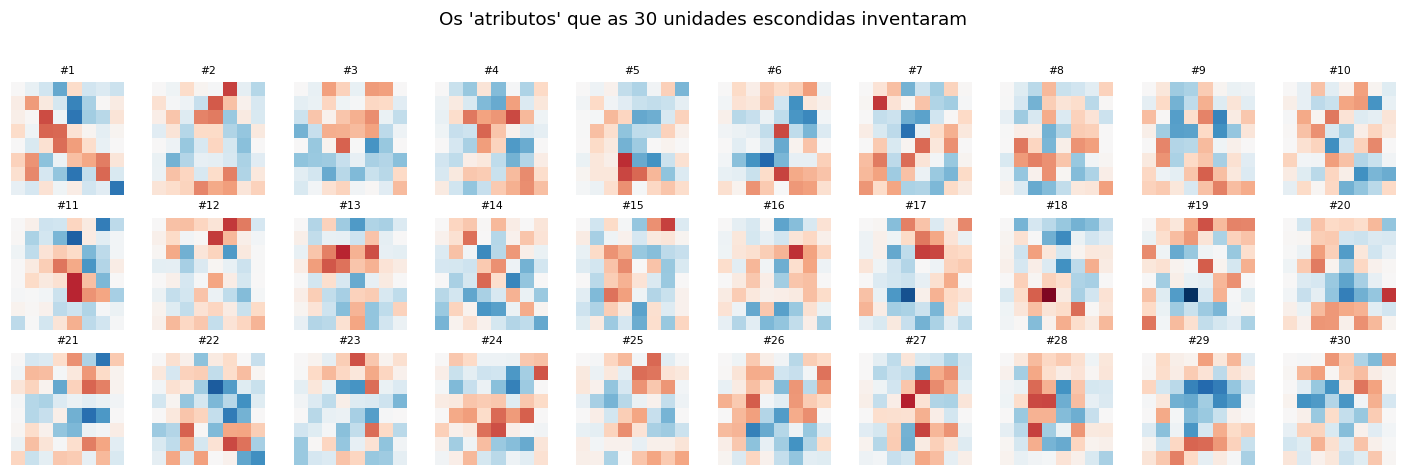

In [43]:
pesos_entrada = rede_dig[-1].coefs_[0]        # (64 pixels, 30 unidades)
print(f"matriz de pesos da 1ª camada: {pesos_entrada.shape}")

limite = np.abs(pesos_entrada).max()
fig, axes = plt.subplots(3, 10, figsize=(13, 4.2))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(pesos_entrada[:, i].reshape(8, 8), cmap="RdBu_r", vmin=-limite, vmax=limite)
    ax.set_title(f"#{i + 1}", fontsize=7)
    ax.axis("off")
fig.suptitle("Os 'atributos' que as 30 unidades escondidas inventaram", y=1.02)
plt.tight_layout()
plt.show()

 camada escondida  parâmetros  acurácia treino  acurácia teste  diferença
                2         160           0.4209          0.4178     0.0032
                5         385           0.9614          0.8711     0.0903
               10         760           0.9948          0.9333     0.0615
               30        2260           1.0000          0.9778     0.0222
              100        7510           1.0000          0.9800     0.0200


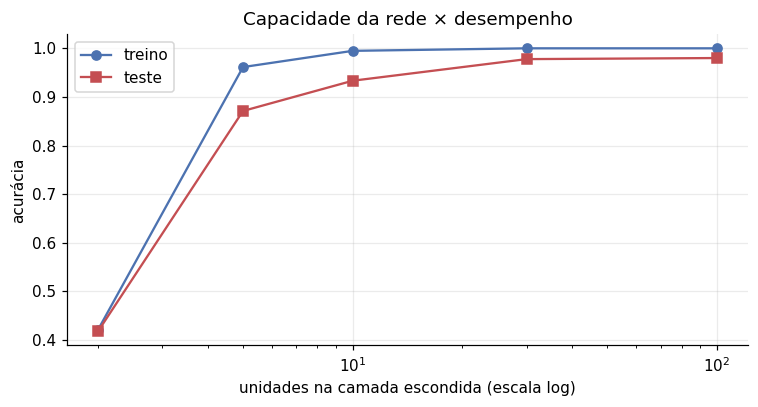

In [44]:
# E o efeito do tamanho da camada escondida sobre treino e teste.
comparacao = []
for tamanho in [(2,), (5,), (10,), (30,), (100,)]:
    m = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=tamanho, activation="logistic",
                      max_iter=600, random_state=RANDOM_STATE),
    ).fit(X_tr, y_tr)
    comparacao.append({
        "camada escondida": tamanho[0],
        "parâmetros": sum(c.size for c in m[-1].coefs_) + sum(b.size for b in m[-1].intercepts_),
        "acurácia treino": m.score(X_tr, y_tr),
        "acurácia teste": m.score(X_te, y_te),
        "diferença": m.score(X_tr, y_tr) - m.score(X_te, y_te),
    })
tabela_tam = pd.DataFrame(comparacao)
print(tabela_tam.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(tabela_tam["camada escondida"], tabela_tam["acurácia treino"], "o-",
        color=CORES[0], label="treino")
ax.plot(tabela_tam["camada escondida"], tabela_tam["acurácia teste"], "s-",
        color=CORES[3], label="teste")
ax.set_xscale("log")
ax.set_xlabel("unidades na camada escondida (escala log)")
ax.set_ylabel("acurácia")
ax.set_title("Capacidade da rede × desempenho")
ax.legend()
plt.tight_layout()
plt.show()

**Responda:**

a) Olhe as 30 imagens de pesos. Elas parecem dígitos? Descreva o que a maioria delas
   parece detectar - e relacione com a frase da seção 9 ("a camada escondida muda de
   coordenadas").

b) Com **2** unidades escondidas a acurácia despenca. Quantos números diferentes uma
   camada de 2 unidades consegue entregar para a camada de saída? Isso é suficiente
   para descrever 10 dígitos?

c) Na tabela, a coluna `diferença` cresce até certo ponto e depois estabiliza. O que
   uma diferença grande entre treino e teste indica? E qual seria o **risco** de
   escolher a arquitetura olhando só a coluna `acurácia treino`?

d) Se você tivesse de escolher uma arquitetura para colocar em produção usando **só**
   esta tabela, qual escolheria - e que informação está faltando aqui para essa
   escolha ser honesta? (Esta última pergunta é a ponte para a aula 05.)

🎯 **Conclusão do Exercício 3**

a) Não parecem dígitos. São manchas: uma região vermelha ao lado de uma azul, em
   posições e orientações diferentes em cada unidade. Cada unidade virou um **detector
   de contraste local** - ela dispara quando há tinta de um lado e papel do outro,
   numa certa região da imagem. Nenhuma delas reconhece um algarismo; juntas, elas
   descrevem cada imagem por 30 números do tipo "tem traço vertical à esquerda?",
   "tem curva embaixo?". É a mudança de coordenadas da seção 9, agora em 64
   dimensões: a camada de saída faz regressão logística **nesses** 30 atributos, e
   não nos 64 pixels crus.

b) Duas unidades entregam um ponto no quadrado $[0,1]^2$ - a imagem inteira comprimida
   em duas coordenadas. Dez classes em duas dimensões é pedir demais: as nuvens se
   sobrepõem, e nenhuma camada de saída desfaz informação que já foi jogada fora. A
   acurácia de ~42% é o teto do que dá para fazer com esse gargalo. Note que aqui o
   problema **não** é overfitting: treino e teste são ruins juntos. É o oposto -
   underfitting, ou *alto bias*, na linguagem dos slides da próxima aula.

c) Diferença grande = a rede vai melhor nos dados que já viu do que nos que não viu,
   ou seja, ela está **decorando** parte do treino em vez de aprender a regra geral.
   Escolher pela acurácia de treino levaria sempre à maior rede possível, que decora
   tudo e chega a 100% - um número que não diz absolutamente nada sobre desempenho
   real. É a lição da aula 01, agora com nome e sobrenome: sem um conjunto separado, a
   medida de qualidade é fraudulenta.

d) Pela tabela, 30 ou 100 unidades - ambas em torno de 98%. Mas a escolha não é
   honesta, por dois motivos. Primeiro, usamos o **conjunto de teste** para escolher a
   arquitetura; a partir do momento em que uma decisão é tomada olhando o teste, ele
   deixa de ser uma estimativa imparcial (por isso existe o conjunto de **validação**).
   Segundo, cada linha é uma única divisão treino/teste - a diferença entre 97,8% e
   98,0% pode ser puro sorteio, e só um esquema de validação cruzada mostraria isso.
   Os dois assuntos abrem a aula 05.

---
## Para a próxima aula

Nesta aula sempre houve alguém de fora dizendo quantas camadas, quantas unidades, que
$\alpha$, quantas iterações. E esses números mudaram tudo: de 42% a 98% de acurácia nos
dígitos, de 0 a 10 acertos em 10 sementes no XOR.

A aula 05 é sobre **escolher esses números com método** - e sobre o buraco entre
treino e teste que apareceu em toda tabela desta aula:

1. como dividir os dados em treino, validação e teste, e por que o teste tem de ficar
   intocado até o fim;
2. como **diagnosticar** pela dupla (erro de treino, erro de validação) se o problema
   é *bias* alto ou *variância* alta - e o que fazer em cada caso;
3. **regularização**: L2 (o famoso *weight decay*), *dropout*, *data augmentation* e
   *early stopping*.

Uma pergunta para levar na cabeça: nos dígitos, a rede de 100 unidades chegou a 100%
no treino. Se ela acerta tudo o que viu, por que ainda erra 2% do que não viu - e por
que **diminuir** a liberdade dela pode melhorar esse número?